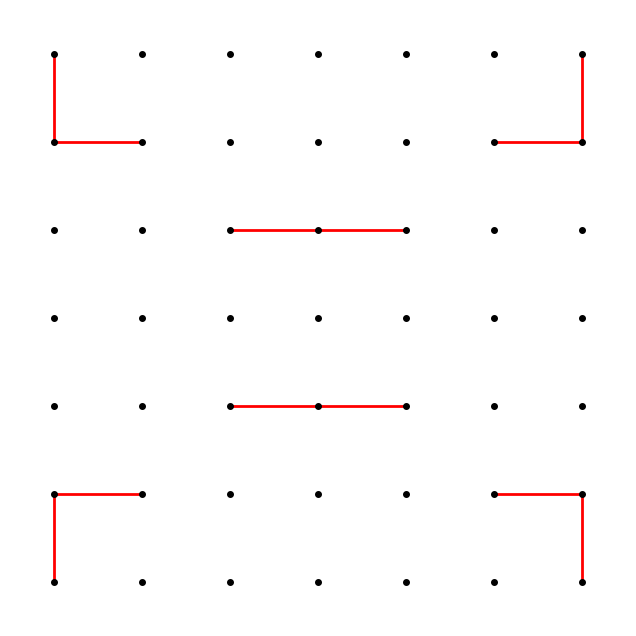

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 创建图形和坐标轴
fig, ax = plt.subplots(figsize=(8, 8))

# 首先创建4×4的随机图形
np.random.seed(42)  # 设置随机种子以便结果可复现
size_small = 4

# 创建边的集合，使用字典来跟踪边的出现次数
edges = {}

# 随机生成4×4图形中的边
for _ in range(10):  # 随机添加一些边
    x1, y1 = np.random.randint(1, size_small+1, 2)
    x2, y2 = np.random.randint(1, size_small+1, 2)
    
    # 确保是相邻的点
    while abs(x1-x2) + abs(y1-y2) != 1:
        x2, y2 = np.random.randint(1, size_small+1, 2)
    
    edge = ((x1, y1), (x2, y2)) if (x1, y1) < (x2, y2) else ((x2, y2), (x1, y1))
    edges[edge] = edges.get(edge, 0) + 1

# 向外翻折扩展到7×7
size_large = 7
center = 4  # 中心点是(4,4)

# 定义三种翻折映射函数
def mirror_left(x, y):
    return 2*center - x, y  # 水平翻折

def mirror_down(x, y):
    return x, 2*center - y  # 垂直翻折

def mirror_center(x, y):
    return 2*center - x, 2*center - y  # 中心对称翻折

# 扩展边
extended_edges = dict(edges)

# 对原始4×4区域的每条边进行三次翻折
for edge, count in list(extended_edges.items()):
    (x1, y1), (x2, y2) = edge
    
    # 向左翻折
    mx1_left, my1_left = mirror_left(x1, y1)
    mx2_left, my2_left = mirror_left(x2, y2)
    mirrored_edge_left = ((mx1_left, my1_left), (mx2_left, my2_left)) if (mx1_left, my1_left) < (mx2_left, my2_left) else ((mx2_left, my2_left), (mx1_left, my1_left))
    extended_edges[mirrored_edge_left] = extended_edges.get(mirrored_edge_left, 0) + count
    
    # 向下翻折
    mx1_down, my1_down = mirror_down(x1, y1)
    mx2_down, my2_down = mirror_down(x2, y2)
    mirrored_edge_down = ((mx1_down, my1_down), (mx2_down, my2_down)) if (mx1_down, my1_down) < (mx2_down, my2_down) else ((mx2_down, my2_down), (mx1_down, my1_down))
    extended_edges[mirrored_edge_down] = extended_edges.get(mirrored_edge_down, 0) + count
    
    # 中心对称翻折
    mx1_center, my1_center = mirror_center(x1, y1)
    mx2_center, my2_center = mirror_center(x2, y2)
    mirrored_edge_center = ((mx1_center, my1_center), (mx2_center, my2_center)) if (mx1_center, my1_center) < (mx2_center, my2_center) else ((mx2_center, my2_center), (mx1_center, my1_center))
    extended_edges[mirrored_edge_center] = extended_edges.get(mirrored_edge_center, 0) + count

# 根据出现次数保留边（偶数次出现的边被消除）
final_edges = []
for edge, count in extended_edges.items():
    if count % 2 == 1:  # 奇数次出现的边保留
        final_edges.append(edge)

# 绘制最终的图形
for edge in final_edges:
    (x1, y1), (x2, y2) = edge
    ax.plot([x1, x2], [y1, y2], 'r-', linewidth=2)

# 绘制7x7网格点
for x in range(1, size_large+1):
    for y in range(1, size_large+1):
        ax.plot(x, y, 'ko', markersize=4)

# 设置坐标轴范围
ax.set_xlim(0.5, size_large+0.5)
ax.set_ylim(0.5, size_large+0.5)
ax.set_aspect('equal')

# 隐藏坐标轴和网格
ax.axis('off')

plt.show()
